## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


**Team 30**

A01796272 - Luis Antonio Ramirez Martinez

A01796323 - Benjamin Cisneros Barraza

A01796363 - Arthur Jafed Zizumbo Velasco

A01796937 - Sandra Luz Cervantes Espinoza

Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [1]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 816.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [2]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 13.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries


We import the following libraries:

- **torch**: the main deep learning framework used to build and train the Recurrent Neural Network (RNN) model.

- **torch.nn**: provides neural network layers such as `Embedding`, `LSTM`, `Dropout`, and `Linear`, which are used to construct the text classification model.

- **torch.optim**: used to define optimization algorithms such as **Adam**, which updates the model parameters during training.

- **torch.nn.functional**: contains additional neural network functions such as activation functions and loss functions that can be used during training.

- **sklearn.metrics**: used to evaluate the performance of the model. In this project it is used to compute the **confusion matrix** for analyzing classification results.

- **matplotlib**: used to visualize the confusion matrix and other potential plots related to model performance.

- **numpy**: used for numerical operations and array manipulations when processing predictions and labels.

These libraries allow us to build, train, evaluate, and visualize the performance of the RNN-based text classification model using the **AG_NEWS dataset**.
```

In [5]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
import scipy
scipy.interp = np.interp
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scikitplot as skplt
import gc

In [6]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

##Dataset Preparation

AG_NEWS() loads the dataset and splits it into training and test data.

to_map_style_dataset() converts the dataset into a map-style dataset.



In [7]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [8]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [9]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [10]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [11]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [12]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [13]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [14]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [31]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

In [32]:
def collate_batch(batch):
    # Separate labels (y) and texts (x) from the batch
    y, x = list(zip(*batch))

    # Convert each text into a sequence of token IDs using the tokenizer and vocabulary
    token_ids = [vocab(tokeniser(text)) for text in x]

    # Apply padding or truncation so every sequence has the same length
    padded_tokens = [
        tokens + [0] * (max_tokens - len(tokens)) if len(tokens) < max_tokens
        else tokens[:max_tokens]
        for tokens in token_ids
    ]

    # Convert sequences to PyTorch tensors (int64 required for embeddings)
    x_tensor = torch.tensor(padded_tokens, dtype=torch.long)

    # Convert labels to tensor and shift from 1–4 to 0–3
    y_tensor = torch.tensor(y, dtype=torch.long) - 1

    # Return processed inputs and labels
    return x_tensor, y_tensor

In [33]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [34]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [35]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()

        # Embedding layer that converts word IDs into dense vector representations
        self.embedding_layer = nn.Embedding(
            num_embeddings=len(vocab),
            embedding_dim=embed_size
        )

        # Recurrent layer (LSTM), processes the sequence of word embeddings
        # and learns temporal dependencies in the text
        self.rnn = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True
        )

        # Fully connected layer, maps the hidden representation
        # to the final number of output classes
        self.fc = nn.Linear(
            in_features=hidden,
            out_features=num_classes
        )

    def forward(self, x):
        # x shape: [batch_size, sequence_length]

        # Convert token IDs into embeddings
        embedded = self.embedding_layer(x)  # shape: [batch, seq_len, embed_dim]

        # Pass embeddings through the LSTM
        # output: hidden states for all time steps
        # h_n: final hidden state for each layer
        output, (h_n, c_n) = self.rnn(embedded)

        # Take the last hidden state from the final LSTM layer
        # This represents the full sequence information
        last_hidden_state = h_n[-1]  # shape: [batch_size, hidden_size]

        # Pass the representation to the classifier
        logits = self.fc(last_hidden_state)

        return logits

In [36]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [37]:
def train(model, optimiser, train_loader, epochs=10):
    # Loss function for multi-class classification
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:

            x = x.long()
            y = y.long()

            optimiser.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimiser.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

In [38]:
epochs = 3
lr = 0.001
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [39]:
train(rnn_model, optimiser=optimiser, train_loader=train_loader, epochs=epochs)

print("Train Accuracy:", accuracy(rnn_model, train_loader))
print("Val Accuracy:", accuracy(rnn_model, val_loader))
print("Test Accuracy:", accuracy(rnn_model, test_loader))

Epoch 1/3 | Loss: 272.7999
Epoch 2/3 | Loss: 121.9331
Epoch 3/3 | Loss: 87.8612
Train Accuracy: 0.9518518518518518
Val Accuracy: 0.9046666666666666
Test Accuracy: 0.9001315789473684


In [50]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9001


In [51]:
def sample_text(model, loader):

    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
      for x, y in loader:

          # Move tensors to GPU if available
          x = x.to(device)
          y = y.to(device)

          # Forward pass through the model
          outputs = model(x)

          # Get predicted class index
          _, predicted = torch.max(outputs, 1)

          # Iterate through each sample in the batch
          for i in range(x.size(0)):

              # Convert tensor to list (avoids numpy dependency)
              indices = x[i].cpu().tolist()

              # Reconstruct the text by converting token ids back to words
              text_tokens = [
                  vocab.lookup_token(idx)
                  for idx in indices
                  if idx != 0   # ignore padding tokens
              ]

              text_str = " ".join(text_tokens)

              print("Text:", text_str)
              print("Predicted:", labels[predicted[i].item()])
              print("Actual:", labels[y[i].item()])
              print("-" * 60)



In [52]:
sample_text(rnn_model, test_loader)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Text: gold fields hit by q3 rand strength johannesburg ( mineweb . com ) -- gold fields , the takeover target of smaller rival harmony , contained its costs on its south african mines during the september quarter .
Predicted: Business
Actual: Business
------------------------------------------------------------
Text: nissan #39 s supply shortage sends steel stocks up us steelmakers #39 shares rose sharply yesterday , with us steel , allegheny technologies and nucor ( which operates a mill in seattle ) reaching their highest prices in at least seven years , after nissan said the metal is in
Predicted: Business
Actual: Business
------------------------------------------------------------
Text: kim captures 1-shot win at longs drugs ( ap ) ap - christina kim made a charge on the back nine sunday , shooting a 6-under 65 at the longs drugs challenge for a one-shot victory over karrie webb and her first lpga win .
Predicted: 

In [77]:
def plot_confusion_matrix(model, loader, labels):

    model = model.to(device)   # ensure model is on the same device
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = outputs.argmax(dim=1)

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    skplt.metrics.plot_confusion_matrix(y_true, y_pred, figsize=(8,8))

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.title("Confusion Matrix - AG_NEWS")
    plt.show()

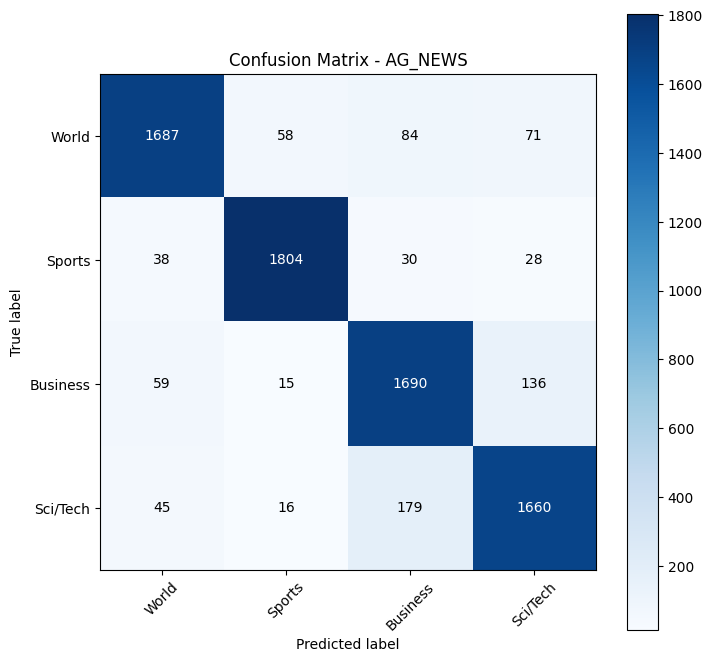

In [78]:
plot_confusion_matrix(rnn_model, test_loader, labels)

Model metrics

In [79]:
from sklearn.metrics import classification_report
import torch

def evaluate_model(model, loader):

    device = next(model.parameters()).device
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            predicted = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().tolist())
            y_pred.extend(predicted.cpu().tolist())

    print(classification_report(
        y_true,
        y_pred,
        target_names=["World","Sports","Business","Sci/Tech"]
    ))


evaluate_model(rnn_model, test_loader)

              precision    recall  f1-score   support

       World       0.92      0.89      0.90      1900
      Sports       0.95      0.95      0.95      1900
    Business       0.85      0.89      0.87      1900
    Sci/Tech       0.88      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



Model predictions

In [80]:
def show_predictions(model, loader, num_examples=5):

    device = next(model.parameters()).device
    model.eval()

    labels_map = ["World","Sports","Business","Sci/Tech"]

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            outputs = model(texts)
            preds = outputs.argmax(dim=1)

            for i in range(num_examples):

                print("Predicción:", labels_map[preds[i]])
                print("Real:", labels_map[labels[i]])
                print("-"*50)

            break


show_predictions(rnn_model, test_loader)

Predicción: World
Real: World
--------------------------------------------------
Predicción: Business
Real: Business
--------------------------------------------------
Predicción: World
Real: World
--------------------------------------------------
Predicción: Sports
Real: Sports
--------------------------------------------------
Predicción: World
Real: World
--------------------------------------------------
